# Notebook 01 — Exploration du Dataset ACNE04

## Objectif
Explorer et comprendre la structure du dataset ACNE04 avant le preprocessing.
On analyse la distribution des classes, la qualité des images et les annotations.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Chemin vers le dataset
BASE_PATH = "../data/images_brutes/Classification"
IMAGES_PATH = os.path.join(BASE_PATH, "JPEGImages")

# Compter le nombre total d'images
images = os.listdir(IMAGES_PATH)
print(f"Nombre total d'images : {len(images)}")

Nombre total d'images : 1457


Dans cette prochaine cellule pour analyser la distribution des classes

In [ ]:
# Lire les fichiers d'annotation pour chaque niveau de sévérité
niveaux = {0: "Pas d'acné", 1: "Légère", 2: "Modérée", 3: "Sévère"}
distribution = {}

for niveau, nom in niveaux.items():
    fichier = os.path.join(BASE_PATH, f"NNEW_trainval_{niveau}.txt")
    with open(fichier, "r") as f:
        lignes = f.readlines()
    distribution[nom] = len(lignes)
    print(f"Niveau {niveau} - {nom} : {len(lignes)} images")

print(f"\nTotal train/val : {sum(distribution.values())} images")

Niveau 0 - Pas d'acné : 1165 images
Niveau 1 - Légère : 1165 images
Niveau 2 - Modérée : 1165 images
Niveau 3 - Sévère : 1165 images

Total train/val : 4660 images


Il y a un porblème , 1165 images par niveau ça fait 4660 au total alors qu'on a seulement 1457 images. Ça veut dire que les fichiers txt ne contiennent pas des listes d'images mais autre chose.On va regarder que contient chaque fichier

In [4]:
# Regarder le contenu d'un fichier annotation
fichier = os.path.join(BASE_PATH, "NNEW_trainval_0.txt")
with open(fichier, "r") as f:
    lignes = f.readlines()

# Afficher les 5 premières lignes
print("5 premières lignes du fichier :")
for ligne in lignes[:5]:
    print(ligne.strip())

5 premières lignes du fichier :
levle0_0.jpg  0  3
levle0_1.jpg  0  3
levle0_100.jpg  0  2
levle0_101.jpg  0  1
levle0_102.jpg  0  3


On voit que pour chaque ligne on a une premiere colonne avec le nom de l'image , la colonne 2 c'est le niveau de sévérité (0,1,2,3) et la 3ème colonne est le nombre de lésions comptées.Les fichiers sont des folds de validation croisée — les mêmes images 
apparaissent dans plusieurs fichiers. On supprimera les doublons à l'étape suivante.

## 2. Construction du dataset propre

In [5]:
# Lire TOUS les fichiers trainval et construire le dataset complet
toutes_annotations = []

for fold in range(5):
    fichier = os.path.join(BASE_PATH, f"NNEW_trainval_{fold}.txt")
    with open(fichier, "r") as f:
        lignes = f.readlines()
    for ligne in lignes:
        parties = ligne.strip().split()
        if len(parties) >= 2:
            toutes_annotations.append({
                "image": parties[0],
                "niveau": int(parties[1]),
                "nb_lesions": int(parties[2])
            })

df_train = pd.DataFrame(toutes_annotations)
print("Distribution des niveaux de sévérité (train) :")
print(df_train["niveau"].value_counts().sort_index())
print(f"\nTotal : {len(df_train)} images")

Distribution des niveaux de sévérité (train) :
niveau
0    2050
1    2530
2     730
3     515
Name: count, dtype: int64

Total : 5825 images


In [6]:
# Supprimer les doublons en gardant une seule entrée par image
df_unique = df_train.drop_duplicates(subset=["image"])

print("Distribution SANS doublons :")
print(df_unique["niveau"].value_counts().sort_index())
print(f"\nTotal images uniques : {len(df_unique)}")

Distribution SANS doublons :
niveau
0    513
1    633
2    182
3    129
Name: count, dtype: int64

Total images uniques : 1457


In [7]:
# Distribution avec pourcentages
total = len(df_unique)
noms_niveaux = {0: "Pas d'acné", 1: "Légère", 2: "Modérée", 3: "Sévère"}

print("Distribution des niveaux de sévérité :")
print("-" * 45)
for niveau in range(4):
    count = df_unique["niveau"].value_counts().sort_index()[niveau]
    pourcentage = (count / total) * 100
    print(f"Niveau {niveau} - {noms_niveaux[niveau]:<15} : {count} images ({pourcentage:.1f}%)")
print("-" * 45)
print(f"Total : {total} images")

Distribution des niveaux de sévérité :
---------------------------------------------
Niveau 0 - Pas d'acné      : 513 images (35.2%)
Niveau 1 - Légère          : 633 images (43.4%)
Niveau 2 - Modérée         : 182 images (12.5%)
Niveau 3 - Sévère          : 129 images (8.9%)
---------------------------------------------
Total : 1457 images


## 3.Distribution des classes

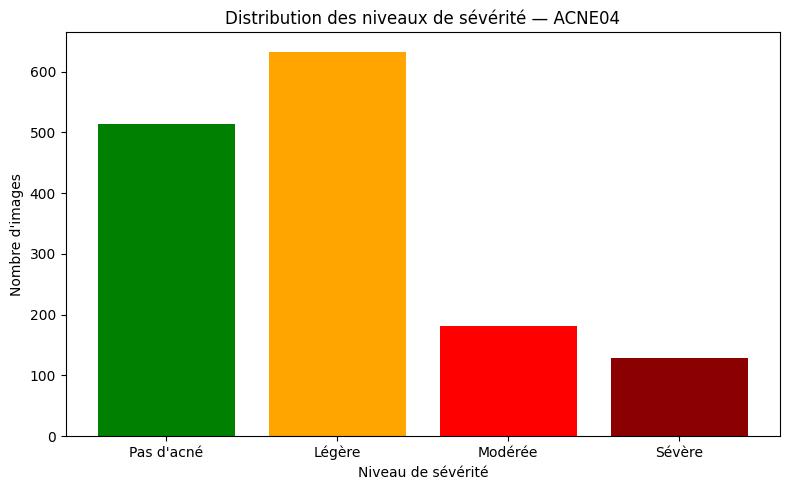

In [8]:
# Visualiser la distribution
noms_niveaux = {0: "Pas d'acné", 1: "Légère", 2: "Modérée", 3: "Sévère"}

plt.figure(figsize=(8, 5))
plt.bar(
    [noms_niveaux[i] for i in range(4)],
    [df_unique["niveau"].value_counts().sort_index()[i] for i in range(4)],
    color=["green", "orange", "red", "darkred"]
)
plt.title("Distribution des niveaux de sévérité — ACNE04")
plt.xlabel("Niveau de sévérité")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

On observe un déséquilibre observé


## 4. Visualisation des images par niveau

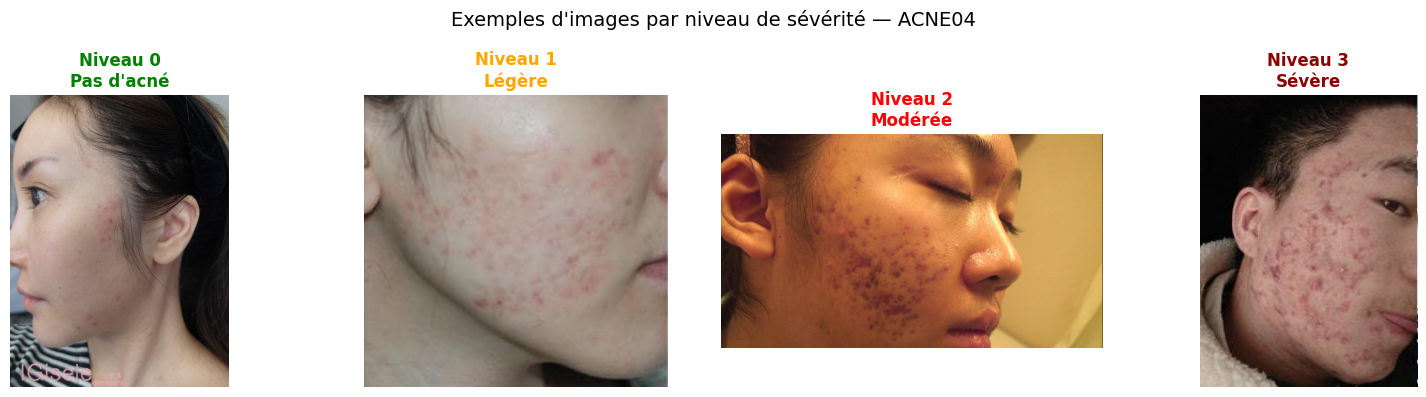

In [9]:
# Afficher un exemple d'image par niveau de sévérité
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

noms_niveaux = {0: "Pas d'acné", 1: "Légère", 2: "Modérée", 3: "Sévère"}
couleurs = {0: "green", 1: "orange", 2: "red", 3: "darkred"}

for niveau in range(4):
    # Prendre la première image de ce niveau
    image_nom = df_unique[df_unique["niveau"] == niveau]["image"].iloc[0]
    image_path = os.path.join(IMAGES_PATH, image_nom)
    
    # Ouvrir et afficher l'image
    img = Image.open(image_path)
    axes[niveau].imshow(img)
    axes[niveau].set_title(f"Niveau {niveau}\n{noms_niveaux[niveau]}", 
                           color=couleurs[niveau], fontsize=12, fontweight="bold")
    axes[niveau].axis("off")

plt.suptitle("Exemples d'images par niveau de sévérité — ACNE04", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Analyse des dimensions

In [10]:
# Analyser les dimensions des images
largeurs = []
hauteurs = []

for image_nom in df_unique["image"].values[:100]:  # on prend 100 images pour aller vite
    image_path = os.path.join(IMAGES_PATH, image_nom)
    img = Image.open(image_path)
    largeur, hauteur = img.size
    largeurs.append(largeur)
    hauteurs.append(hauteur)

print(f"Largeur moyenne : {sum(largeurs)/len(largeurs):.0f} pixels")
print(f"Hauteur moyenne : {sum(hauteurs)/len(hauteurs):.0f} pixels")
print(f"Largeur min : {min(largeurs)} — max : {max(largeurs)}")
print(f"Hauteur min : {min(hauteurs)} — max : {max(hauteurs)}")

Largeur moyenne : 2980 pixels
Hauteur moyenne : 3307 pixels
Largeur min : 331 — max : 3112
Hauteur min : 270 — max : 3456


Les images qu'on a sont énormes , il faut les reduire en 224x224 pour nos résaux de neurones